In this notebook we use `MOCpy` to plot footprints of many surveys used in this catalog.

In [1]:
# !pip install mocpy

In [2]:
import io

import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import Angle, SkyCoord
from minio import Minio
from mocpy import MOC
from mocpy import WCS as World2ScreenMPL

matplotlib.rcParams.update(
    {
        "font.size": 22,
        "pgf.rcfonts": False,
        # "font.family": "serif",
        # "font.serif": "Computer Modern Roman",
        # "pgf.texsystem": "pdflatex",
        # "text.usetex": True,
    }
)


MINIO_ENDPOINT_URL = "1491-152-84-248-250.ngrok-free.app"
ACCESS_KEY = "slcomp"
SECRET_KEY = "slcomp@data"
client = Minio(
    MINIO_ENDPOINT_URL,
    access_key=ACCESS_KEY,
    secret_key=SECRET_KEY,
    secure=True,
)

In [3]:
database_object = client.get_object("slcomp", "Data/Database.csv").data
database = pd.read_csv(
    io.StringIO(database_object.decode("utf-8")),
    low_memory=False,
    usecols=["JNAME", "RA", "DEC"],
).convert_dtypes()
database.head()

,JNAME,RA,DEC
0,J000001.1-350334.9,0.00471,-35.05971
1,J000001.2+051908.6,0.00504,5.31906
2,J000002.2+085518.4,0.00925,8.92179
3,J000006.0+081629.7,0.02512,8.27492
4,J000006.1+213829.4,0.02542,21.6415


In [4]:
photometric_match_object = client.get_object(
    "slcomp", "Data/Photometric_Match.csv"
).data
photometric_match = pd.read_csv(
    io.StringIO(photometric_match_object.decode("utf-8")),
    low_memory=False,
    usecols=["JNAME", "RA", "DEC"],
).convert_dtypes()
photometric_match.head()

,JNAME,RA,DEC
0,J000001.2+051908.6,0.00504,5.31906
1,J000006.1+213829.4,0.02542,21.6415
2,J000008.9+211702.8,0.03692,21.2841
3,J000014.7-055702.8,0.06112,-5.95079
4,J000018.9+001617.7,0.07883,0.27158


In [5]:
spectroscopic_match_object = client.get_object(
    "slcomp", "Data/Spectroscopic_Match.csv"
).data
spectroscopic_match = pd.read_csv(
    io.StringIO(spectroscopic_match_object.decode("utf-8")),
    low_memory=False,
    usecols=["JNAME", "RA", "DEC", "Catalog_Name"],
).convert_dtypes()
spectroscopic_match.head()

,JNAME,RA,DEC,Catalog_Name
0,J000006.9-633539.7,0.02858,-63.59437,CfA
1,J000020.8-002051.0,0.08679,-0.3475,SDSS DR17 § HSC Wide DR3
2,J000025.6+283211.9,0.10646,28.53665,SDSS DR17
3,J000101.1-003328.3,0.25442,-0.55785,SDSS DR17 § HSC Wide DR3
4,J000106.0+234605.3,0.27508,23.76815,SDSS DR17


In [6]:
len(database), len(photometric_match), len(spectroscopic_match)

(31569, 17154, 6440)

# Imaging Surveys

The surveys we obtained cutouts for all objects in this survey were the following:

* Dark Energy Spectroscopic Instrument (DESI) **Legacy** Survey: Beijing-Arizona Sky Survey (BASS), Dark Energy Camera Legacy Survey (DECaLS) and Mayall z-band Legacy Survey (MzLS) 
  - Telescopes:
    - BASS: Bok (2.3 m)
    - DECaLS: Blanco (4 m)
    - MzLS: Mayall (4 m )
  - Survey area: 14,000 deg² (https://www.legacysurvey.org)
* Dark Energy Survey (**DES**)
  - Telescope: Blanco (4 m)
  - Survey area: 5,000 deg² (https://www.darkenergysurvey.org)
* Hyper Suprime-Cam (**HSC**) Subaru Strategic Survey
  - Telescope: Subaru (8.2 m)
  - Survey area: 1,400 deg² (https://hsc-release.mtk.nao.ac.jp)
  - Source for footprint: https://hsc-release.mtk.nao.ac.jp/doc/index.php/tools-2/
* Kilo-Degree Survey (**KiDS**)
  - Telescope: VLT Survey Telescope (2.6 m)
  - Survey area: 1,350 deg² (http://kids.strw.leidenuniv.nl)
* Red Cluster Sequence Lensing Survey (**RCSLenS**)
  - Telescope: Canada–France–Hawaii (4.2 m)
  - Survey area: 700 deg² (http://www.rcslens.org)
* Canada-France Hawaii Telescope Stripe 82 Survey (**CS82**)
  - Telescope: Canada–France–Hawaii (4.2 m)
  - Survey area: 184 deg² (http://icra.cbpf.br/twiki/bin/view/CS82/SC82ProjectStatus)
* Canada-France Hawaii Telescope Lensing Survey (**CFHTLenS**)* Kilo-Degree Survey DR 3 (KiDS)
    - Source for footprint: same as for imaging
  - Telescope: Canada–France–Hawaii (4.2 m)
  - Survey area: 154 deg² (https://www.cfhtlens.org)

In [7]:
# Legacy DR8
LegacyNorth = MOC.from_url(
    "https://cdsarc.cds.unistra.fr/ftp/VII/292/tab_7292_1_VII_292_north.moc.fits"
)  # https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/292
LegacySouth = MOC.from_url(
    "https://cdsarc.cds.unistra.fr/ftp/VII/292/tab_7292_2_VII_292_south.moc.fits"
)  # https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/292
Legacy = (LegacyNorth.extended().union(LegacySouth.extended())).extended()

# DES DR2
DES = MOC.from_vizier_table(
    "II/371/des_dr2"
).extended()  # https://cdsarc.cds.unistra.fr/viz-bin/cat/II/371

# HSC DR2
HSC_Deep = MOC.load("data/mocs/CDS-P-HSC-DR2-deep-color-i-r-g_MOC.fits", "fits")
HSC_Wide = MOC.load("data/mocs/CDS-P-HSC-DR2-wide-color-i-r-g_MOC.fits", "fits")
HSC = (HSC_Wide.extended().union(HSC_Deep.extended())).extended()

# KiDS DR2
KiDS = MOC.from_vizier_table("II/347/kids_dr3").extended()

# RCSLenS
RCSLenS = MOC.from_vizier_table("J/A+A/584/A44/table3").extended()

# CS82:
# J/ApJ/794/120/catalog small band
CS82 = MOC.from_vizier_table("J/A+A/578/A79/tablea1").extended()

# CFHTLenS:
CFHLenS_Deep = MOC.from_vizier_table("II/317/cfhtls_d")
CFHLenS_Wide = MOC.from_vizier_table("II/317/cfhtls_w")
CFHTLS = (CFHLenS_Wide.extended().union(CFHLenS_Deep.extended())).extended()

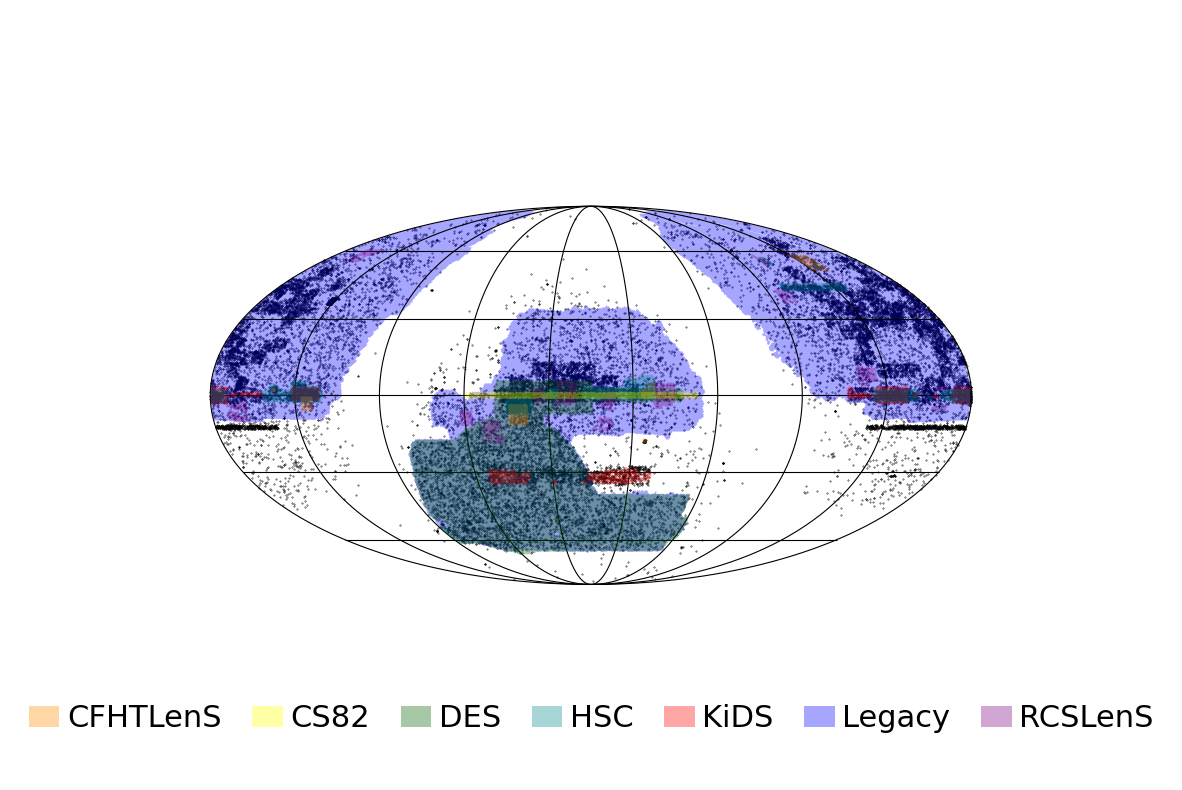

In [8]:
fill = True
linewidth = 0
alpha = 0.35

fig = plt.figure(111, figsize=(15, 10), frameon=False)

with World2ScreenMPL(
    fig,
    fov=330 * u.deg,
    center=SkyCoord(0, 0, unit="deg", frame="icrs"),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="MOL",
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_format_unit("deg")
    lon.set_ticks(np.linspace(-180, 180, 10) * u.degree)
    ax.scatter(
        database.RA.values,
        database.DEC.values,
        0.1,
        color="black",
        transform=ax.get_transform("world"),
        zorder=0,
    )
    Legacy.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="blue",
        linewidth=linewidth,
        zorder=1,
    )
    Legacy.border(ax=ax, wcs=wcs, alpha=alpha, color="blue", label="Legacy", zorder=2)
    DES.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkgreen",
        linewidth=linewidth,
        zorder=3,
    )
    DES.border(ax=ax, wcs=wcs, alpha=alpha, color="darkgreen", label="DES", zorder=4)
    RCSLenS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="purple",
        linewidth=linewidth,
        zorder=5,
    )
    RCSLenS.border(
        ax=ax, wcs=wcs, alpha=alpha, color="purple", label="RCSLenS", zorder=6
    )
    KiDS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="red",
        linewidth=linewidth,
        zorder=7,
    )
    KiDS.border(ax=ax, wcs=wcs, alpha=alpha, color="red", label="KiDS", zorder=8)
    CFHTLS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkorange",
        linewidth=linewidth,
        zorder=9,
    )
    CFHTLS.border(
        ax=ax, wcs=wcs, alpha=alpha, color="darkorange", label="CFHTLenS", zorder=10
    )
    HSC.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkcyan",
        linewidth=linewidth,
        zorder=11,
    )
    HSC.border(ax=ax, wcs=wcs, alpha=alpha, color="darkcyan", label="HSC", zorder=12)
    CS82.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="yellow",
        linewidth=linewidth,
        zorder=13,
    )
    CS82.border(ax=ax, wcs=wcs, alpha=alpha, color="yellow", label="CS82", zorder=14)
    ax.get_legend()
    ax.coords.frame.set_linewidth(0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
for hs in handles:
    hs.set_lw(0)
plt.legend(
    handles,
    labels,
    framealpha=False,
    bbox_to_anchor=(0.5, 0.025),
    loc="lower center",
    ncol=7,
    columnspacing=1,
    handlelength=1.0,
    handletextpad=0.25,
)
plt.grid(color="black", linestyle="-", zorder=0, alpha=1)
# plt.savefig(
#     "results/imaging_surveys.png", dpi=150, bbox_inches="tight", transparent=True
# )
plt.show()

# Photometric Surveys

* Sloan Digital Sky Survey DR17 (SDSS)
  - Telescope: Sloan Foundation (2.5 m)
  - Survey area: 14,555 deg² (https://www.sdss.org)
* Hyper Suprime-Cam Subaru Strategic Program DR3 (HSC)
* DESI Legacy Imaging Surveys DR9 (Legacy)
* Dark Energy Survey DR2 (DES)
* Canada-France-Hawaii Telescope Legacy Survey (CFHTLS Deep/Wide)
* CS82 (CS82)
* Kilo-Degree Survey DR 3 (KiDS)
* DECam Local Volume Exploration Survey (DELVE)
  - Telescope: Blanco (4 m)
  - Survey area: 5,000 deg² (https://delve-survey.github.io)

In [9]:
# SDSS DR16
SDSS = MOC.from_vizier_table("V/154/sdss16").extended()

# HSC DR2
HSC_Deep = MOC.load("data/mocs/CDS-P-HSC-DR2-deep-color-i-r-g_MOC.fits", "fits")
HSC_Wide = MOC.load("data/mocs/CDS-P-HSC-DR2-wide-color-i-r-g_MOC.fits", "fits")
HSC = (HSC_Wide.extended().union(HSC_Deep.extended())).extended()

# Legacy DR8
LegacyNorth = MOC.from_url(
    "https://cdsarc.cds.unistra.fr/ftp/VII/292/tab_7292_1_VII_292_north.moc.fits"
)  # https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/292
LegacySouth = MOC.from_url(
    "https://cdsarc.cds.unistra.fr/ftp/VII/292/tab_7292_2_VII_292_south.moc.fits"
)  # https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/292
Legacy = (LegacyNorth.extended().union(LegacySouth.extended())).extended()

# DES DR2
DES = MOC.from_vizier_table(
    "II/371/des_dr2"
).extended()  # https://cdsarc.cds.unistra.fr/viz-bin/cat/II/371

# CFHTLenS:
CFHLenS_Deep = MOC.from_vizier_table("II/317/cfhtls_d")
CFHLenS_Wide = MOC.from_vizier_table("II/317/cfhtls_w")
CFHTLS = (CFHLenS_Wide.extended().union(CFHLenS_Deep.extended())).extended()

# CS82:
# J/ApJ/794/120/catalog small band
CS82 = MOC.from_vizier_table("J/A+A/578/A79/tablea1").extended()

# KiDS DR2
KiDS = MOC.from_vizier_table("II/347/kids_dr3").extended()

# DELVE DR2
DELVE = MOC.load("data/mocs/moc_delve_objects.fits", "fits")

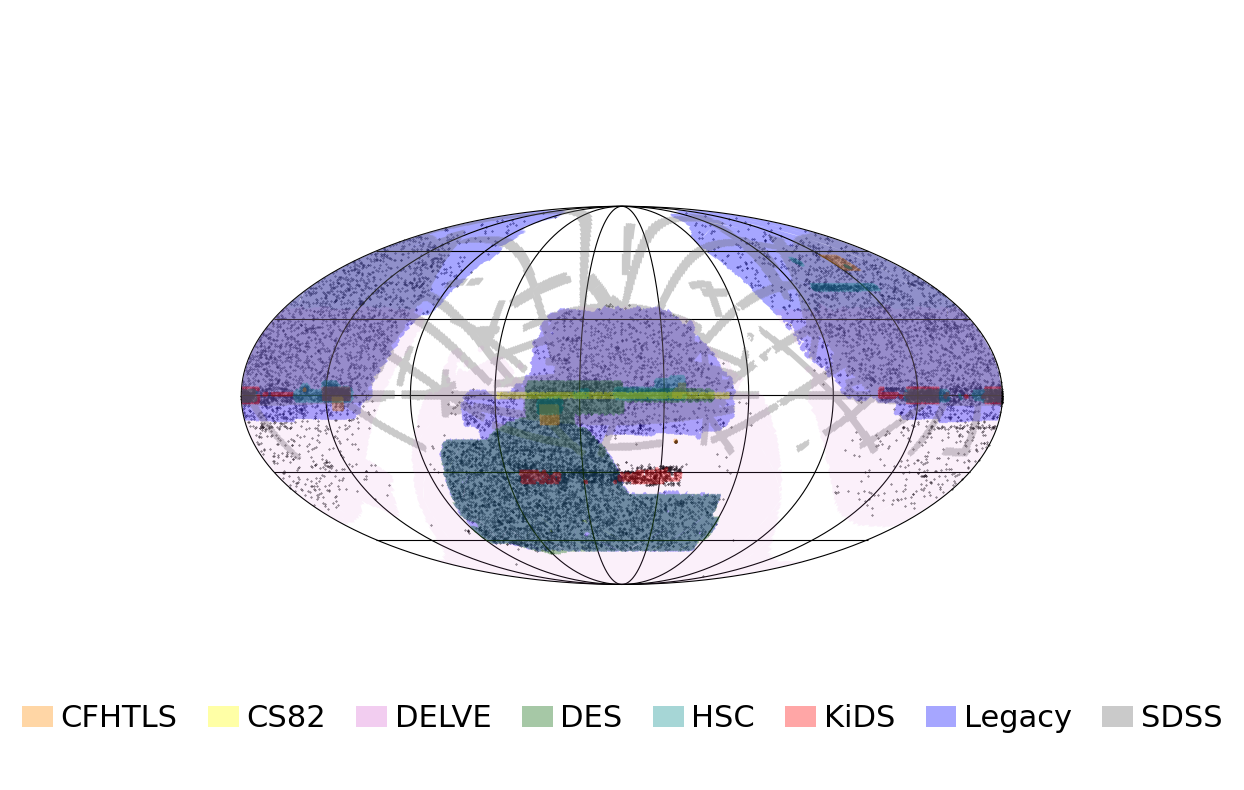

In [10]:
fill = True
linewidth = 0
alpha = 0.35

fig = plt.figure(111, figsize=(15, 10), frameon=False)

with World2ScreenMPL(
    fig,
    fov=330 * u.deg,
    center=SkyCoord(0, 0, unit="deg", frame="icrs"),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="MOL",
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_format_unit("deg")
    lon.set_ticks(np.linspace(-180, 180, 10) * u.degree)
    ax.scatter(
        photometric_match.RA.values,
        photometric_match.DEC.values,
        0.1,
        color="black",
        transform=ax.get_transform("world"),
        zorder=0,
    )
    Legacy.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="blue",
        linewidth=linewidth,
        zorder=1,
    )
    Legacy.border(ax=ax, wcs=wcs, alpha=alpha, color="blue", label="Legacy", zorder=2)
    SDSS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="dimgrey",
        linewidth=linewidth,
        zorder=3,
    )
    SDSS.border(ax=ax, wcs=wcs, alpha=alpha, color="dimgrey", label="SDSS", zorder=4)
    DELVE.fill(
        ax=ax,
        wcs=wcs,
        alpha=0.1,
        fill=fill,
        color="orchid",
        linewidth=linewidth,
        zorder=5,
    )
    DELVE.border(ax=ax, wcs=wcs, alpha=alpha, color="orchid", label="DELVE", zorder=6)
    DES.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkgreen",
        linewidth=linewidth,
        zorder=7,
    )
    DES.border(ax=ax, wcs=wcs, alpha=alpha, color="darkgreen", label="DES", zorder=8)
    KiDS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="red",
        linewidth=linewidth,
        zorder=9,
    )
    KiDS.border(ax=ax, wcs=wcs, alpha=alpha, color="red", label="KiDS", zorder=10)
    CFHTLS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkorange",
        linewidth=linewidth,
        zorder=11,
    )
    CFHTLS.border(
        ax=ax, wcs=wcs, alpha=alpha, color="darkorange", label="CFHTLS", zorder=12
    )
    HSC.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkcyan",
        linewidth=linewidth,
        zorder=13,
    )
    HSC.border(ax=ax, wcs=wcs, alpha=alpha, color="darkcyan", label="HSC", zorder=14)
    CS82.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="yellow",
        linewidth=linewidth,
        zorder=15,
    )
    CS82.border(ax=ax, wcs=wcs, alpha=alpha, color="yellow", label="CS82", zorder=16)
    ax.get_legend()
    ax.coords.frame.set_linewidth(0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
for hs in handles:
    hs.set_lw(0)
plt.legend(
    handles,
    labels,
    framealpha=0,
    bbox_to_anchor=(0.5, 0.025),
    loc="lower center",
    ncol=8,
    columnspacing=1,
    handlelength=1.0,
    handletextpad=0.25,
)
plt.grid(color="black", linestyle="-", zorder=0, alpha=1)
# plt.savefig(
#     "results/photometric_surveys.png", dpi=150, bbox_inches="tight", transparent=True
# )
plt.show()

# Spectroscopic Surveys

* Sloan Digital Sky Survey (SDSS)
  - Source for footprint: same as for photometric
* 2dF Galaxy Redshift Survey (2dF)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/250 (2dfgrs)
* Galaxy And Mass Assembly (GAMA)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/MNRAS/474/3875 (gamadr3)
* OzDES (OzDES)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/MNRAS/472/273 (ozdesdr1)
* WiggleZ Dark Energy Survey (WiggleZ)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/MNRAS/401/1429 (wigglez1)
* 2dF-SDSS LRG and QSO Survey (2SLAQ)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/MNRAS/392/19 (2slaqqso)
* 6dF Galaxy Survey (6dF)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/259 (spectra)
* Large Sky Area Multi-Object Fiber Spectroscopic Telescope Survey (LAMOST)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/V/156 (dr7)
* Southern Sky Redshift Survey (SSRS)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/AJ/116/1 (table2 and table3)
* CfA Redshift Survey (CfA)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/193 (zcat)
* 2MASS Redshift Survey (2MASS)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/ApJS/199/26 (table3)
* PSCz catalogue (PSCz)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/221 (pscz)
* Las Campanas Redshift Survey (LCRS)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/203 (catalog)
* VIMOS VLT Deep Survey (VIMOS)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/A+A/559/A14 (cdfsdeep, f02deep, f02udeep, f10wide, f14wide, f22wide)
* VIMOS Public Extragalactic Redshift Survey (VIPERS)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/A+A/562/A23 (w1spdr1, w4spdr1)
* DEEP2 Redshift Survey (DEEP2)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/III/268 (deep2all)
* zCOSMOS (zCOSMOS)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/ApJ/753/121 (table5)
* Canadian Network for Observational Cosmology Field Galaxy Redshift Survey (CNOC)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/ApJS/129/475 (cnoc0223)
* AGN and Galaxy Evolution Survey (AGES)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/ApJS/200/8 (table2)
* Millennium Galaxy Catalogue (MGC)
  - Source for footprint: https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/240 (mgczcat)

In [11]:
SDSS = MOC.from_vizier_table("V/154/sdss16").extended()
GAMA = MOC.from_vizier_table("J/MNRAS/474/3875/gamadr3").extended()
OzDES = MOC.from_vizier_table("J/MNRAS/472/273/ozdesdr1").extended()
WiggleZ = MOC.from_vizier_table("J/MNRAS/401/1429/wigglez1").extended()
twoSLAQ = MOC.from_vizier_table("J/MNRAS/392/19/2slaqqso").extended()
twodF = MOC.from_vizier_table("VII/250/2dfgrs").extended()
sixdF = MOC.from_vizier_table("VII/259/spectra").extended()
LAMOST = MOC.from_vizier_table("V/156/dr7lrs").extended()
SSRS = MOC.from_vizier_table("J/AJ/116/1/galaxies").extended()
LCRS = MOC.from_vizier_table("VII/203/catalog").extended()
VIMOS_cdfsdeep = MOC.from_vizier_table("J/A+A/559/A14/cdfsdeep").extended()
VIMOS_f02deep = MOC.from_vizier_table("J/A+A/559/A14/f02deep").extended()
VIMOS_f02udeep = MOC.from_vizier_table("J/A+A/559/A14/f02udeep").extended()
VIMOS_f10wide = MOC.from_vizier_table("J/A+A/559/A14/f10wide").extended()
VIMOS_f14wide = MOC.from_vizier_table("J/A+A/559/A14/f14wide").extended()
VIMOS_f22wide = MOC.from_vizier_table("J/A+A/559/A14/f22wide").extended()
VIMOS = VIMOS_f22wide.union(
    VIMOS_f14wide.union(
        VIMOS_f10wide.union(VIMOS_f02udeep.union(VIMOS_f02deep.union(VIMOS_cdfsdeep)))
    )
).extended()
VIPERS = MOC.from_vizier_table("J/A+A/562/A23/spectro").extended()
DEEP2 = MOC.from_vizier_table("III/268/deep2all").extended()
zCOSMOS = MOC.from_vizier_table("J/ApJ/753/121/table5").extended()
CNOC = MOC.from_vizier_table("J/ApJS/129/475/cnoc0223").extended()
AGES = MOC.from_vizier_table("J/ApJS/200/8/table2").extended()
MGC = MOC.from_vizier_table("VII/240/mgczcat").extended()
twoMASS = MOC.from_vizier_table("J/ApJS/199/26/table3").extended()
PSCz = MOC.from_vizier_table("VII/221/pscz").extended()
CfA = MOC.from_vizier_table("VII/193/zcat").extended()

In [12]:
data = spectroscopic_match[
    spectroscopic_match.Catalog_Name.str.contains(
        "|".join(
            [
                "GAMA",
                "OzDES",
                "WiggleZ",
                "2SLAQ",
                "LCRS",
                "VIMOS",
                "VIPERS",
                "DEEP2",
                "zCOSMOS",
                "AGES",
                "CNOC",
                "MGC",
            ]
        )
    )
]
data.head()

,JNAME,RA,DEC,Catalog_Name
154,J003441.8-431418.8,8.67421,-43.23857,OzDES DR2
157,J003448.9-421403.3,8.70367,-42.23426,OzDES DR2
165,J003653.6-444953.6,9.22321,-44.83155,OzDES DR2
184,J004050.0-440750.4,10.20823,-44.13066,OzDES DR2
657,J020149.3-055435.6,30.45562,-5.9099,SDSS DR17 § HSC Wide DR3 § VIPERS


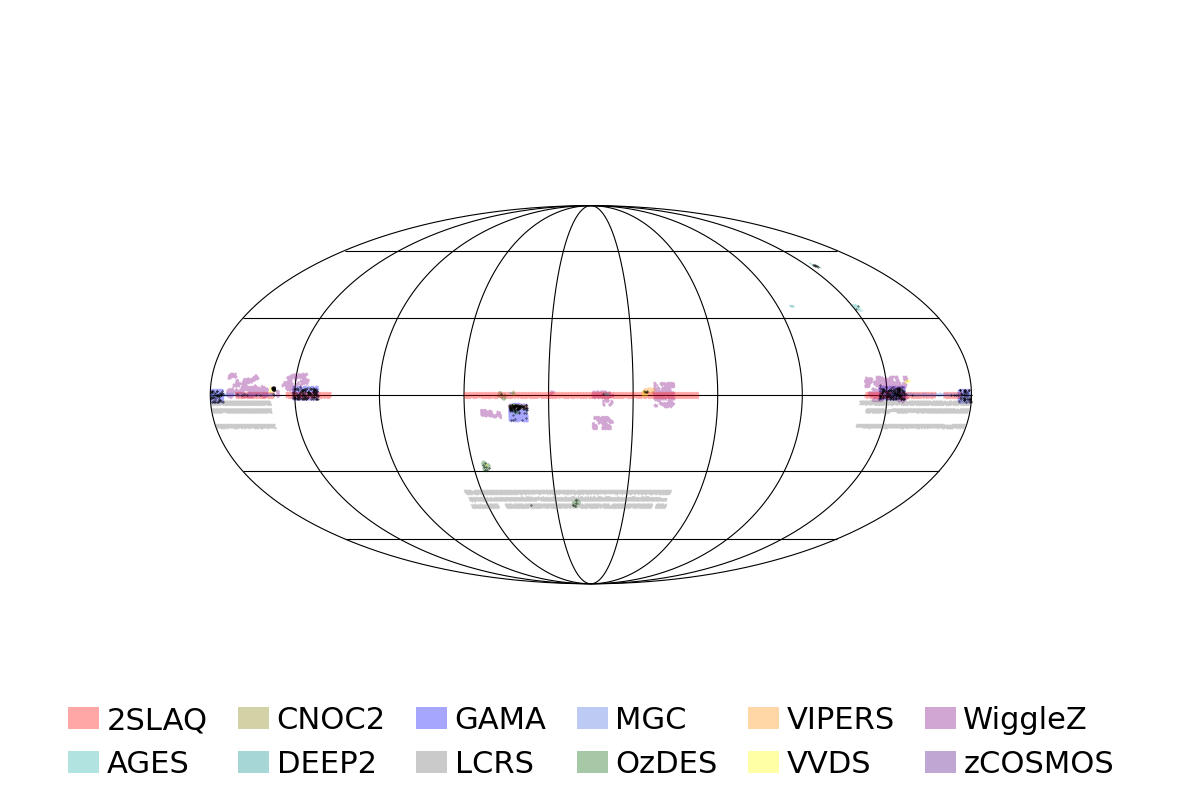

In [13]:
fill = True
linewidth = 0
alpha = 0.35

fig = plt.figure(111, figsize=(15, 10))

with World2ScreenMPL(
    fig,
    fov=330 * u.deg,
    center=SkyCoord(0, 0, unit="deg", frame="icrs"),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="MOL",
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_format_unit("deg")
    lon.set_ticks(np.linspace(-180, 180, 10) * u.degree)
    # Small Surveys:
    ax.scatter(
        data.RA.values,
        data.DEC.values,
        0.1,
        color="black",
        transform=ax.get_transform("world"),
        zorder=25,
    )
    GAMA.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="blue",
        linewidth=linewidth,
        zorder=1,
    )
    GAMA.border(ax=ax, wcs=wcs, alpha=alpha, color="blue", label="GAMA", zorder=2)
    OzDES.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkgreen",
        linewidth=linewidth,
        rasterized=True,
        zorder=3,
    )
    OzDES.border(
        ax=ax, wcs=wcs, alpha=alpha, color="darkgreen", label="OzDES", zorder=4
    )
    WiggleZ.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="purple",
        linewidth=linewidth,
        rasterized=True,
        zorder=5,
    )
    WiggleZ.border(
        ax=ax, wcs=wcs, alpha=alpha, color="purple", label="WiggleZ", zorder=6
    )
    twoSLAQ.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="red",
        linewidth=linewidth,
        rasterized=True,
        zorder=7,
    )
    twoSLAQ.border(ax=ax, wcs=wcs, alpha=alpha, color="red", label="2SLAQ", zorder=8)
    LCRS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="dimgrey",
        linewidth=linewidth,
        rasterized=True,
        zorder=9,
    )
    LCRS.border(ax=ax, wcs=wcs, alpha=alpha, color="dimgrey", label="LCRS", zorder=10)
    VIMOS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="yellow",
        linewidth=linewidth,
        rasterized=True,
        zorder=11,
    )
    VIMOS.border(ax=ax, wcs=wcs, alpha=alpha, color="yellow", label="VVDS", zorder=12)
    VIPERS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkorange",
        linewidth=linewidth,
        rasterized=True,
        zorder=13,
    )
    VIPERS.border(
        ax=ax, wcs=wcs, alpha=alpha, color="darkorange", label="VIPERS", zorder=14
    )
    DEEP2.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkcyan",
        linewidth=linewidth,
        rasterized=True,
        zorder=15,
    )
    DEEP2.border(
        ax=ax, wcs=wcs, alpha=alpha, color="darkcyan", label="DEEP2", zorder=16
    )
    zCOSMOS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="indigo",
        linewidth=linewidth,
        rasterized=True,
        zorder=17,
    )
    zCOSMOS.border(
        ax=ax, wcs=wcs, alpha=alpha, color="indigo", label="zCOSMOS", zorder=18
    )
    CNOC.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="olive",
        linewidth=linewidth,
        rasterized=True,
        zorder=19,
    )
    CNOC.border(ax=ax, wcs=wcs, alpha=alpha, color="olive", label="CNOC2", zorder=20)
    AGES.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="lightseagreen",
        linewidth=linewidth,
        rasterized=True,
        zorder=21,
    )
    AGES.border(
        ax=ax, wcs=wcs, alpha=alpha, color="lightseagreen", label="AGES", zorder=22
    )
    MGC.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="royalblue",
        linewidth=linewidth,
        rasterized=True,
        zorder=23,
    )
    MGC.border(ax=ax, wcs=wcs, alpha=alpha, color="royalblue", label="MGC", zorder=24)
    ax.get_legend()
    ax.coords.frame.set_linewidth(0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
for hs in handles:
    hs.set_lw(0)
plt.legend(
    handles,
    labels,
    framealpha=0,
    bbox_to_anchor=(0.5, -0.035),
    loc="lower center",
    ncol=6,
    columnspacing=1,
    handlelength=1.0,
    handletextpad=0.25,
)
plt.grid(color="black", linestyle="-", zorder=0, alpha=1)
# plt.savefig(
#     "results/spectroscopic_surveys_small_with_matched_objects.png",
#     dpi=150,
#     bbox_inches="tight",
#     transparent=True,
# )
plt.show()

In [14]:
data = spectroscopic_match[
    spectroscopic_match.Catalog_Name.str.contains(
        "|".join(["SSRS", "SDSS", "2dF", "6dF", "LAMOST"])
    )
]
data.head()

,JNAME,RA,DEC,Catalog_Name
1,J000020.8-002051.0,0.08679,-0.3475,SDSS DR17 § HSC Wide DR3
2,J000025.6+283211.9,0.10646,28.53665,SDSS DR17
3,J000101.1-003328.3,0.25442,-0.55785,SDSS DR17 § HSC Wide DR3
4,J000106.0+234605.3,0.27508,23.76815,SDSS DR17
5,J000106.5+010329.8,0.27708,1.05829,SDSS DR17 § HSC Wide DR3


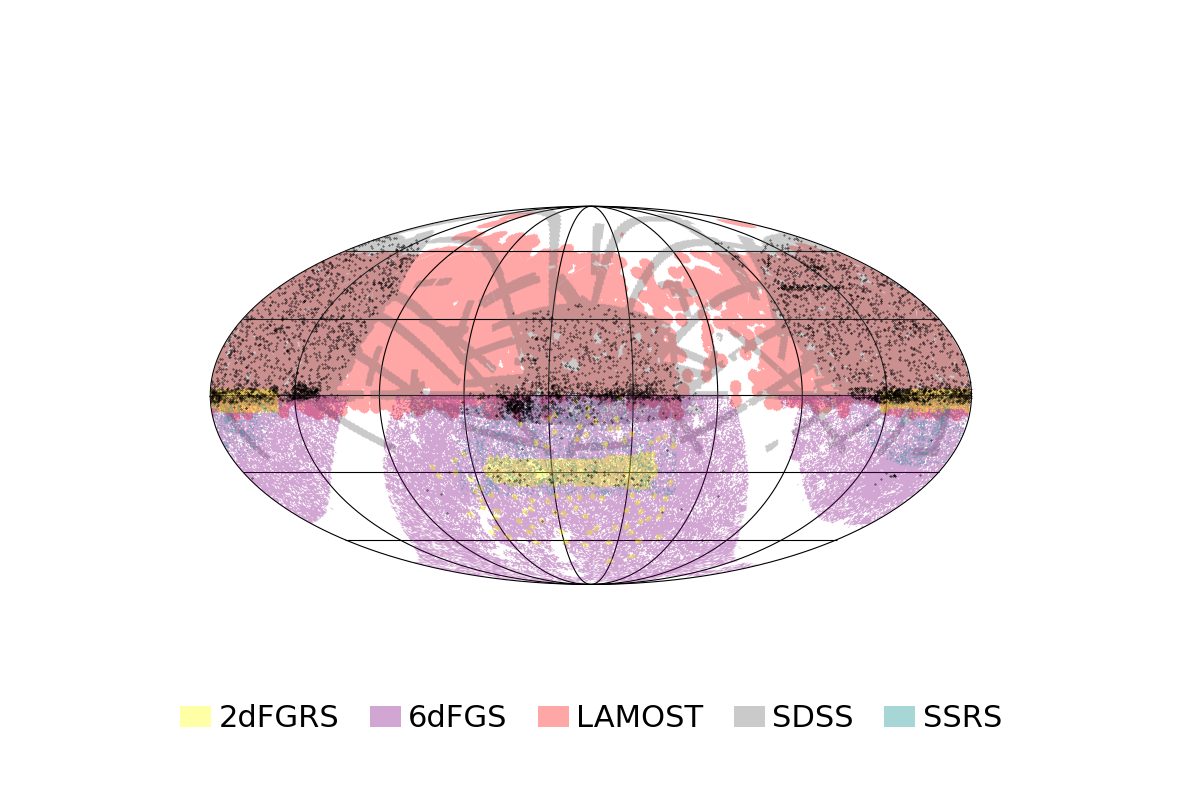

In [15]:
fill = True
linewidth = 0
alpha = 0.35

fig = plt.figure(111, figsize=(15, 10))

with World2ScreenMPL(
    fig,
    fov=330 * u.deg,
    center=SkyCoord(0, 0, unit="deg", frame="icrs"),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="MOL",
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_format_unit("deg")
    lon.set_ticks(np.linspace(-180, 180, 10) * u.degree)
    # Medium Surveys:
    SSRS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="darkcyan",
        linewidth=linewidth,
        zorder=9,
        rasterized=True,
    )
    SSRS.border(ax=ax, wcs=wcs, alpha=alpha, color="darkcyan", label="SSRS", zorder=10)
    SDSS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="dimgrey",
        linewidth=linewidth,
        zorder=3,
        rasterized=True,
    )
    SDSS.border(ax=ax, wcs=wcs, alpha=alpha, color="dimgrey", label="SDSS", zorder=4)
    twodF.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="yellow",
        linewidth=linewidth,
        zorder=7,
        rasterized=True,
    )
    twodF.border(ax=ax, wcs=wcs, alpha=alpha, color="yellow", label="2dFGRS", zorder=8)
    sixdF.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="purple",
        linewidth=linewidth,
        zorder=5,
        rasterized=True,
    )
    sixdF.border(ax=ax, wcs=wcs, alpha=alpha, color="purple", label="6dFGS", zorder=6)
    LAMOST.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="red",
        linewidth=linewidth,
        zorder=1,
        rasterized=True,
    )
    LAMOST.border(ax=ax, wcs=wcs, alpha=alpha, color="red", label="LAMOST", zorder=2)
    ax.scatter(
        data.RA.values,
        data.DEC.values,
        0.1,
        color="black",
        transform=ax.get_transform("world"),
        zorder=11,
    )
    ax.get_legend()
    ax.coords.frame.set_linewidth(0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
for hs in handles:
    hs.set_lw(0)
plt.legend(
    handles,
    labels,
    framealpha=0,
    bbox_to_anchor=(0.5, 0.025),
    loc="lower center",
    ncol=5,
    columnspacing=1,
    handlelength=1.0,
    handletextpad=0.25,
)
plt.grid(color="black", linestyle="-", zorder=0, alpha=1)
# plt.savefig(
#     "results/spectroscopic_surveys_medium_with_matched_objects.png",
#     dpi=150,
#     bbox_inches="tight",
#     transparent=True,
# )
plt.show()

In [16]:
data = spectroscopic_match[
    spectroscopic_match.Catalog_Name.str.contains("|".join(["2MASS", "PSCz", "CfA"]))
]
data.head()

,JNAME,RA,DEC,Catalog_Name
0,J000006.9-633539.7,0.02858,-63.59437,CfA
27,J000505.9-414828.4,1.27442,-41.8079,CfA
46,J000940.0-021427.1,2.4165,-2.24085,CfA
51,J001020.0-352638.8,2.58321,-35.44411,CfA
68,J001420.6-302401.1,3.58604,-30.4003,CfA


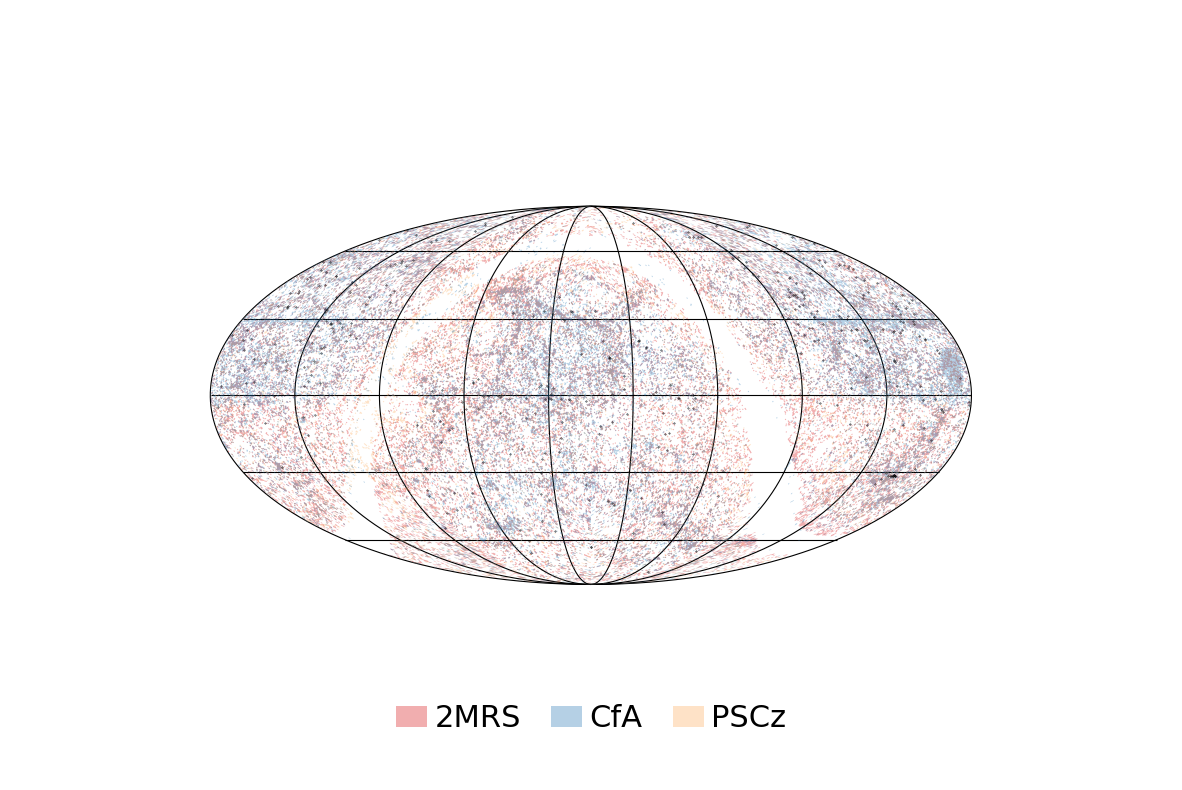

In [17]:
fill = True
linewidth = 0
alpha = 0.35

fig = plt.figure(111, figsize=(15, 10))

with World2ScreenMPL(
    fig,
    fov=330 * u.deg,
    center=SkyCoord(0, 0, unit="deg", frame="icrs"),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="MOL",
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_format_unit("deg")
    lon.set_ticks(np.linspace(-180, 180, 10) * u.degree)
    # Full Sky:
    twoMASS.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="#d7191c",
        linewidth=linewidth,
        rasterized=True,
        zorder=1,
    )
    twoMASS.border(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        color="#d7191c",
        label="2MRS",
        rasterized=True,
        zorder=2,
    )
    PSCz.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="#fdae61",
        linewidth=linewidth,
        rasterized=True,
        zorder=3,
    )
    PSCz.border(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        color="#fdae61",
        label="PSCz",
        rasterized=True,
        zorder=4,
    )
    CfA.fill(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        fill=fill,
        color="#2c7bb6",
        linewidth=linewidth,
        rasterized=True,
        zorder=5,
    )
    CfA.border(
        ax=ax,
        wcs=wcs,
        alpha=alpha,
        color="#2c7bb6",
        label="CfA",
        rasterized=True,
        zorder=6,
    )
    ax.scatter(
        data.RA.values,
        data.DEC.values,
        0.1,
        color="black",
        transform=ax.get_transform("world"),
        zorder=7,
    )
    ax.get_legend()
    ax.coords.frame.set_linewidth(0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
for hs in handles:
    hs.set_lw(0)
plt.legend(
    handles,
    labels,
    framealpha=0,
    bbox_to_anchor=(0.5, 0.025),
    loc="lower center",
    ncol=3,
    columnspacing=1,
    handlelength=1.0,
    handletextpad=0.25,
)
plt.grid(color="black", linestyle="-", zorder=0, alpha=1)
# plt.savefig(
#     "results/spectroscopic_surveys_large_with_matched_objects.png",
#     dpi=150,
#     bbox_inches="tight",
#     transparent=True,
# )
plt.show()

```bash
for f in results/*.png; do 
        convert -trim "$f" "$f"
done
```

```bash
for FILE in *.pdf; do
  pdfcrop "${FILE}" "${FILE}"
done
```

In [18]:
# %%bash
# for f in results/*.png; do
#         convert -trim "$f" "$f"
# done